# Quantization

In [ ]:
!pip install onnx onnxruntime onnx-simplifier segmentation-models-pytorch

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import onnx
from onnx import shape_inference
from onnxsim import simplify
from onnxruntime.quantization import quantize_dynamic, QuantType

# ================= CONFIG =================
CHECKPOINT_PATH = r"E:\FPT\DAP391m\model\best_model_resnet101.pth"
DEVICE = "cpu"

# ================= MODEL ARCHITECTURE (Giữ nguyên) =================
class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dims, out_dims, 1, bias=False)
        self.conv2 = nn.Conv2d(in_dims, out_dims, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_dims, out_dims, 3, padding=12, dilation=12, bias=False)
        self.conv_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dims, out_dims, 1, bias=False))
        self.fuse = nn.Sequential(nn.Conv2d(out_dims*4, out_dims, 1), nn.BatchNorm2d(out_dims), nn.ReLU())

    def forward(self, x):
        h, w = x.shape[-2:]
        res = [self.conv1(x), self.conv2(x), self.conv3(x),
            torch.nn.functional.interpolate(self.conv_pool(x), size=(h,w), mode='bilinear', align_corners=True)]
        return self.fuse(torch.cat(res, dim=1))

class FlexibleFloodModel(nn.Module):
    def __init__(self, encoder_name='resnet101'):
        super().__init__()
        self.base = smp.Unet(encoder_name=encoder_name, encoder_weights=None, in_channels=8, classes=1, decoder_attention_type='scse')
        ch = self.base.encoder.out_channels[-1]
        self.aspp = ASPP(ch, ch)

    def forward(self, x):
        feats = self.base.encoder(x)
        feats[-1] = self.aspp(feats[-1])
        dec = self.base.decoder(feats)
        return self.base.segmentation_head(dec)

# ================= PIPELINE FUNCTION (FIXED FOR WINDOWS) =================
def run_quantization_pipeline():
    fp32_path = "flood_temp_fp32.onnx"
    final_web_model = "flood_resnet101_web_int8.onnx"

    # Dọn dẹp các file rác cũ (nếu có) trước khi chạy
    for f in [fp32_path, final_web_model, "flood_temp_simp.onnx"]:
        if os.path.exists(f):
            try: os.remove(f)
            except: pass

    print("🚀 Bắt đầu Pipeline chuyển đổi model cho Web...")

    # 1. Load PyTorch Model
    model = FlexibleFloodModel(encoder_name='resnet101').to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()

    # 2. Export sang ONNX
    print("🔄 Bước 1: Export sang định dạng ONNX...")
    dummy_input = torch.randn(1, 8, 256, 256).to(DEVICE)
    torch.onnx.export(
        model, dummy_input, fp32_path,
        export_params=True, opset_version=12, do_constant_folding=True,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {2: 'height', 3: 'width'}, 'output': {2: 'height', 3: 'width'}},
        # dynamo=False # Mở comment nếu dùng Torch 2.4+
    )

    # 3. Simplify và Shape Inference (Làm trên bộ nhớ để tránh lỗi Lock file)
    print("⚡ Bước 2: Tối ưu hóa và Tính toán Shape...")
    onnx_model = onnx.load(fp32_path)
    
    # Tối ưu hóa cấu trúc
    model_simp, check = simplify(onnx_model)
    if not check:
        print("⚠️ Simplify không thành công, dùng bản gốc.")
        model_simp = onnx_model

    # Quan trọng: Thực hiện Shape Inference thủ công ngay tại đây
    model_inferred = shape_inference.infer_shapes(model_simp)

    # 4. Quantization (Truyền Object model thay vì Path file)
    print("💎 Bước 3: Nén mô hình xuống INT8...")
    # Khi truyền model_input là một đối tượng ModelProto, onnxruntime sẽ ít bị lỗi lock file hơn
    quantize_dynamic(
        model_input=model_inferred, 
        model_output=final_web_model,
        weight_type=QuantType.QUInt8
    )

    # 5. Thông số cuối
    size_old = os.path.getsize(CHECKPOINT_PATH) / (1024*1024)
    size_new = os.path.getsize(final_web_model) / (1024*1024)
    
    print("\n" + "="*40)
    print("🎉 HOÀN THÀNH!")
    print(f"🔹 File gốc (.pth): {size_old:.2f} MB")
    print(f"🔹 File Web (INT8): {size_new:.2f} MB")
    print(f"📍 File sẵn sàng: {final_web_model}")
    print("="*40)

    # Dọn dẹp file tạm duy nhất còn lại
    if os.path.exists(fp32_path):
        os.remove(fp32_path)

if __name__ == "__main__":
    run_quantization_pipeline()

🚀 Bắt đầu Pipeline chuyển đổi model cho Web...
🔄 Bước 1: Export sang định dạng ONNX...


C:\Users\acerg\AppData\Local\Temp\ipykernel_22620\2916740812.py:69: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0319 21:01:45.416000 22620 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0319 21:01:45.952000 22620 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]',

[torch.onnx] Obtain model graph for `FlexibleFloodModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FlexibleFloodModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


d:\Application\Anaconda\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "d:\Application\Anaconda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "d:\Application\Anaconda\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "d:\Application\Anaconda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "d:\Application\Anaconda\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(mo

Applied 235 of general pattern rewrite rules.
⚡ Bước 2: Tối ưu hóa và Tính toán Shape...
💎 Bước 3: Nén mô hình xuống INT8...



🎉 HOÀN THÀNH!
🔹 File gốc (.pth): 1757.63 MB
🔹 File Web (INT8): 146.73 MB
📍 File sẵn sàng: flood_resnet101_web_int8.onnx


# Inference onnx

d:\Application\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


🚀 ONNX FILE: Sample_2020-05-07.npz
📊 NSE: 0.5076 | MSE: 0.011847 | MAE: 0.0883


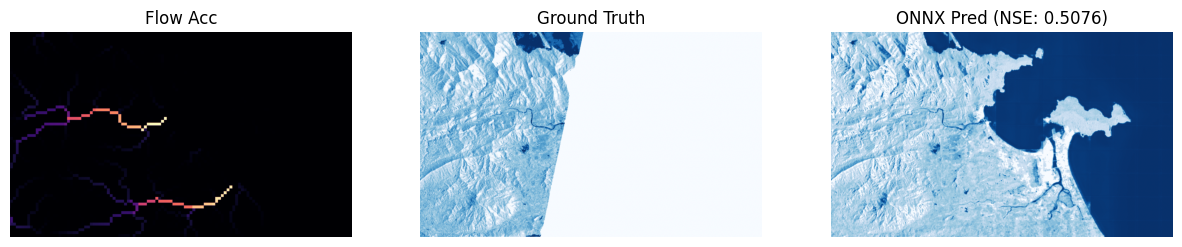

📊 Bắt đầu Batch Evaluation với ONNX (85 files)...


100%|██████████| 85/85 [09:11<00:00,  6.49s/it]



✅ KẾT QUẢ TRUNG BÌNH ONNX:
NSE     0.545125
MSE     0.025159
MAE     0.126539
RMSE    0.155037
KGE     0.720829
R2      0.545125
dtype: float64

🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):
                     file       MSE       NSE       MAE
73  Sample_2025-04-29.npz  0.008496  0.630559  0.068948
35  Sample_2022-03-10.npz  0.009233  0.617508  0.071419
23  Sample_2021-05-02.npz  0.009300  0.680035  0.076142
20  Sample_2021-03-03.npz  0.009493  0.666612  0.075458
17  Sample_2021-01-26.npz  0.009682  0.591769  0.072052


In [2]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import random
import onnxruntime as ort
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error # Thêm mean_squared_error
from skimage.restoration import denoise_nl_means, estimate_sigma

# ================= CONFIG =================
MODEL_ONNX_PATH = "flood_resnet101_web_int8.onnx" 
FOLDER_PATH = r"E:\FPT\DAP391m\model\outputres101\test"
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.15

# Cấu hình Hardware Acceleration
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if ort.get_device() == 'GPU' else ['CPUExecutionProvider']
session = ort.InferenceSession(MODEL_ONNX_PATH, providers=providers)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# ================= UTILS & METRICS (Updated with MSE) =================
def calculate_masked_metrics(y_true, y_pred):
    mask = (y_true > 0.001) & (y_true < 0.999) 
    if not np.any(mask): return 0, 0, 0, 0, 0, 0 # Thêm các giá trị mặc định
    
    y_t, y_p = y_true[mask], y_pred[mask]
    
    mae = np.mean(np.abs(y_t - y_p))
    mse = mean_squared_error(y_t, y_p) # Bổ sung MSE
    rmse = np.sqrt(mse) # Có thể tính thêm RMSE nếu muốn
    
    nse = 1 - (np.sum((y_t - y_p)**2) / (np.sum((y_t - np.mean(y_t))**2) + 1e-10))
    r2 = r2_score(y_t, y_p)
    
    # KGE
    r = np.corrcoef(y_t, y_p)[0, 1] if np.std(y_p) > 0 else 0
    alpha = np.std(y_p) / (np.std(y_t) + 1e-10)
    beta = np.mean(y_p) / (np.mean(y_t) + 1e-10)
    kge = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    
    return mae, mse, rmse, r2, nse, kge

def sota_denoise(y_pred):
    img = y_pred.astype(np.float64)
    sigma_est = np.mean(estimate_sigma(img, channel_axis=None))
    return denoise_nl_means(img, h=0.8 * sigma_est, fast_mode=True, patch_size=5, patch_distance=6)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ================= 3. ONNX INFERENCE ENGINE (Updated) =================
def smart_inference_onnx(test_files, folder_path, g_min, g_max):
    file_name = random.choice(test_files)
    data = np.load(os.path.join(folder_path, file_name))
    x_full, y_true = data['x'], data['y']
    h, w = y_true.shape

    g_min_tile = g_min.reshape(8, 1, 1)
    g_max_tile = g_max.reshape(8, 1, 1)

    pad_h = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE
    pad_w = (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
    x_padded = np.pad(x_full, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
    h_p, w_p = x_padded.shape[1:]

    y_pred_sum = np.zeros((h_p, w_p))
    y_count = np.zeros((h_p, w_p))

    for i in range(0, h_p - PATCH_SIZE + 1, STRIDE):
        for j in range(0, w_p - PATCH_SIZE + 1, STRIDE):
            patch = x_padded[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            patch = (patch - g_min_tile) / (g_max_tile - g_min_tile + 1e-7)
            patch = patch[np.newaxis, ...].astype(np.float32)
            
            outputs = session.run([output_name], {input_name: patch})
            pred = sigmoid(outputs[0].squeeze())
            
            y_pred_sum[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += pred
            y_count[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 1

    y_p = np.divide(y_pred_sum, y_count, out=np.zeros_like(y_pred_sum), where=y_count!=0)[:h, :w]
    y_p = sota_denoise(y_p)
    y_p[y_p < THRESHOLD] = 0
    if y_p.max() > 0:
        y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
    y_p = np.clip(y_p, 0, 1)

    # Metrics
    mae, mse, rmse, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
    print(f"🚀 ONNX FILE: {file_name}")
    print(f"📊 NSE: {nse:.4f} | MSE: {mse:.6f} | MAE: {mae:.4f}")

    plt.figure(figsize=(15, 5))
    plt.subplot(131); plt.imshow(data['x'][7], cmap='magma'); plt.title("Flow Acc"); plt.axis('off')
    plt.subplot(132); plt.imshow(y_true, cmap='Blues'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(133); plt.imshow(y_p, cmap='Blues'); plt.title(f"ONNX Pred (NSE: {nse:.4f})"); plt.axis('off')
    plt.show()

# ================= 4. BATCH EVALUATION ONNX (Updated) =================
def batch_evaluate_onnx(test_files, folder_path, g_min, g_max):
    results = []
    g_min_tile = g_min.reshape(8, 1, 1)
    g_max_tile = g_max.reshape(8, 1, 1)
    
    print(f"📊 Bắt đầu Batch Evaluation với ONNX ({len(test_files)} files)...")
    for file_name in tqdm(test_files):
        try:
            data = np.load(os.path.join(folder_path, file_name))
            x_full, y_true = data['x'], data['y']
            h, w = y_true.shape

            pad_h, pad_w = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE, (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
            x_p = np.pad(x_full, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
            y_pred_full = np.zeros(x_p.shape[1:])

            for i in range(0, x_p.shape[1] - PATCH_SIZE + 1, PATCH_SIZE):
                for j in range(0, x_p.shape[2] - PATCH_SIZE + 1, PATCH_SIZE):
                    patch = x_p[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                    patch = (patch - g_min_tile) / (g_max_tile - g_min_tile + 1e-7)
                    patch = patch[np.newaxis, ...].astype(np.float32)
                    
                    outputs = session.run([output_name], {input_name: patch})
                    y_pred_full[i:i+PATCH_SIZE, j:j+PATCH_SIZE] = sigmoid(outputs[0].squeeze())
            
            y_p = y_pred_full[:h, :w]
            y_p = sota_denoise(y_p)
            y_p[y_p < THRESHOLD] = 0
            if y_p.max() > 0: y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
            
            mae, mse, rmse, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
            results.append({
                'file': file_name, 
                'NSE': nse, 
                'MSE': mse, 
                'MAE': mae, 
                'RMSE': rmse, 
                'KGE': kge,
                'R2': r2
            })
        except Exception as e:
            print(f"Error {file_name}: {e}")
            
    return pd.DataFrame(results)

# ================= RUN =================
if __name__ == "__main__":
    all_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.npz')]
    
    # Tính toán g_min, g_max (Tốt nhất là lấy từ checkpoint lúc train)
    all_min, all_max = [], []
    for f in random.sample(all_files, min(30, len(all_files))):
        d = np.load(os.path.join(FOLDER_PATH, f))['x']
        all_min.append(d.min(axis=(1,2))); all_max.append(d.max(axis=(1,2)))
    g_min = np.array(all_min).min(axis=0)
    g_max = np.array(all_max).max(axis=0)

    # 1. Test 1 file
    smart_inference_onnx(all_files, FOLDER_PATH, g_min, g_max)

    # 2. Batch test
    df = batch_evaluate_onnx(all_files, FOLDER_PATH, g_min, g_max)
    print("\n✅ KẾT QUẢ TRUNG BÌNH ONNX:")
    print(df.mean(numeric_only=True))
    
    # Hiển thị Top 5 file có MSE thấp nhất (tốt nhất)
    print("\n🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):")
    print(df.sort_values('MSE', ascending=True)[['file', 'MSE', 'NSE', 'MAE']].head(5))